In [17]:
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
from data.arbitrage import audit_dataset

%matplotlib inline

In [18]:
import yaml

with open("configs/smoke.yaml") as f:
    cfg = yaml.safe_load(f)

DATA_PATH = "outputs/smoke_train.h5"
PARAM_NAMES  = ["kappa", "theta", "xi", "rho", "v0"]
PARAM_BOUNDS = {
    name: (cfg["heston"][name][0], cfg["heston"][name][1])
    for name in PARAM_NAMES
}


In [19]:
def load_h5(path):
    with h5py.File(path, "r") as f:
        surfaces = f["surfaces"][:]
        params = f["parameters"][:]
        grid_k = f["grid_k"][:]
        grid_tau = f["grid_tau"][:]
    return surfaces, params, grid_k, grid_tau

surfaces, params, grid_k, grid_tau = load_h5(DATA_PATH)
N, n_k, n_tau = surfaces.shape

print(surfaces.shape)   # (1000, 16, 20)
print(params.shape)     # (1000, 5)
print(grid_k.shape)     # (16,)
print(grid_tau.shape)   # (20,)

(1000, 16, 20)
(1000, 5)
(16,)
(20,)


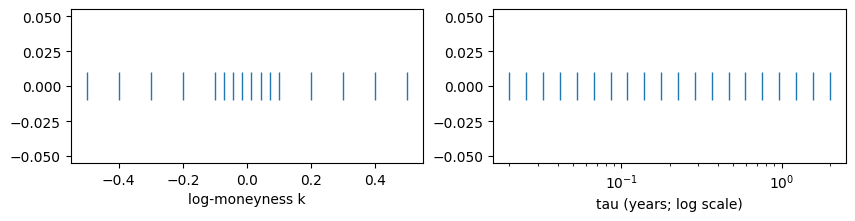

k spacings: [0.1    0.1    0.1    0.1    0.0286 0.0286 0.0286 0.0286 0.0286 0.0286
 0.0286 0.1    0.1    0.1    0.1   ]
tau spacings: [0.0055 0.007  0.0089 0.0114 0.0145 0.0184 0.0235 0.0299 0.0381 0.0486
 0.0619 0.0789 0.1005 0.1281 0.1633 0.208  0.2651 0.3378 0.4305]


In [20]:
# Grid Inspection: visual sanity check with 

fig, axes = plt.subplots(1, 2, figsize=(10, 2))

# k-grid
axes[0].plot(grid_k, np.zeros_like(grid_k), "|", markersize = 20)
axes[0].set_xlabel("log-moneyness k")

axes[1].plot(grid_tau, np.zeros_like(grid_tau), "|", markersize=20)
axes[1].set_xscale("log") # Tau grid is geometrically spaced
axes[1].set_xlabel("tau (years; log scale)")

plt.show()

# For phase 0, we are looking for an ATM-dense k-grid 
# and a geometric tau-grid (even on log scale).

print(f"k spacings: {np.diff(grid_k).round(4)}")
print(f"tau spacings: {np.diff(grid_tau).round(4)}")

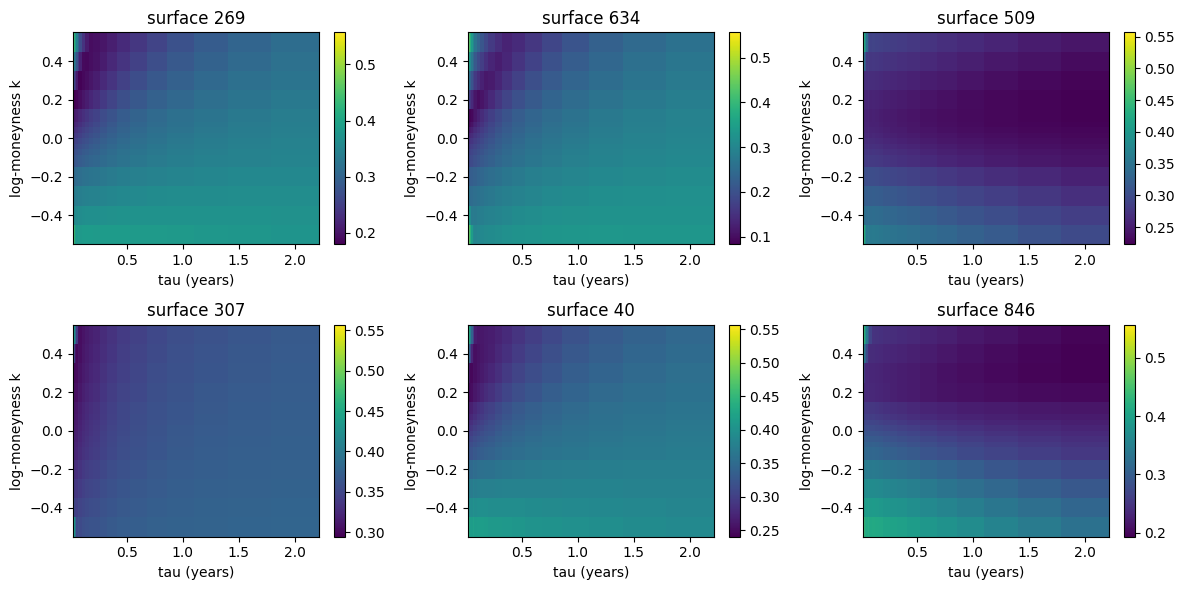

In [21]:
# Surface Heatmap - visual sanity check on a random sample of IV surfaces

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

rng = np.random.default_rng(0)
idxs = rng.choice(N, size=6, replace=False)

for ax, idx in zip(axes.flat, idxs):
    im = ax.pcolormesh(grid_tau, grid_k, surfaces[idx], shading="auto")
    fig.colorbar(im, ax=ax)
    ax.set_xlabel("tau (years)")
    ax.set_ylabel("log-moneyness k")
    ax.set_title(f"surface {idx}")

plt.tight_layout()
plt.show()

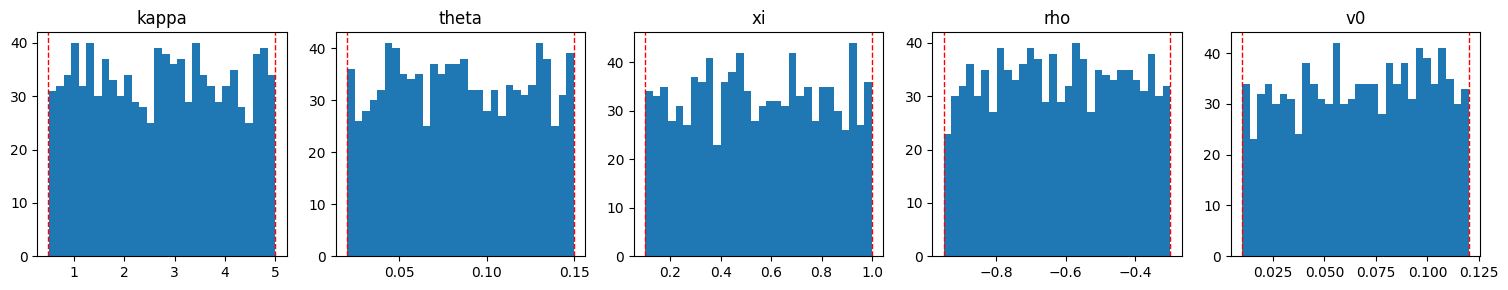

In [22]:
# Parameter Histograms - confirms if LHS is covering the parameter space evenly

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, name in zip(axes, PARAM_NAMES):
    ax.hist(params[:, PARAM_NAMES.index(name)], bins=30)
    lo, hi = PARAM_BOUNDS[name]
    ax.set_title(name)
    ax.axvline(lo, color='r', linestyle='--', linewidth=1)
    ax.axvline(hi, color='r', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

In [23]:
# IV Statistics - confirms the values are in a reasonable range

print(f"IV min:  {surfaces.min():.4f}")
print(f"IV max:  {surfaces.max():.4f}")
print(f"IV mean: {surfaces.mean():.4f}")
print(f"IV std:  {surfaces.std():.4f}")

IV min:  0.0446
IV max:  0.5569
IV mean: 0.2740
IV std:  0.0764


In [24]:
# Arbitrage Audit - check for calendar and butterfly violations across the dataset

from data.arbitrage import _d2_dk2_nonuniform

audit = audit_dataset(surfaces, grid_k, grid_tau)

# Computes the worst margins for calendar and butterfly violations
w_all = (surfaces ** 2) * grid_tau[None, None, :]
worst_cal = np.diff(w_all, axis=2).min()
worst_btf = min(
    _d2_dk2_nonuniform((iv ** 2) * grid_tau[None, :], grid_k).min()
    for iv in surfaces
)

CAL_TOL = 1e-4 # Calendar tolerance
BTF_TOL = 1e-1 # Butterfly tolerance

print(f"Total surfaces:        {audit['n_total']}")
print(f"Negative IV:           {audit['negative_iv']}")
print(f"Calendar violations:   {audit['calendar_violations']}  (worst margin:{worst_cal:+.2e}, tol: -{CAL_TOL:.0e})")
print(f"Butterfly violations:  {audit['butterfly_violations']}  (worst margin:{worst_btf:+.2e}, tol: -{BTF_TOL:.0e})")

Total surfaces:        1000
Negative IV:           0
Calendar violations:   0  (worst margin:-1.54e-05, tol: -1e-04)
Butterfly violations:  0  (worst margin:-9.56e-02, tol: -1e-01)
